**Import des librairies**

In [1]:
!pip install ipywidgets
!pip install joblib
!pip install scikit-learn
!pip install xgboost
!pip install torch
!pip install pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 12.4 MB/s eta 0:00:00


In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import random
import numpy as np
from collections import defaultdict
import ipywidgets as widgets
from IPython.display import display
import joblib
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import pandas as pd
from math import pi


**Création d'un batiment avec des propriétés aléatoires**

In [3]:
def creer_batiment_3D():

    # Surface du bâtiment avec une valeur moyenne de 318 m²
    surface = int(318 * random.uniform(0.7, 1.3))

    # Ratio largeur/profondeur aléatoire (0.5 = profond, 2.0 = large)
    ratio = random.uniform(0.5, 2.0)
    largeur = int((surface * ratio) ** 0.5)
    profondeur = max(1, int(surface / max(largeur, 1)))
    hauteur = max(1, int(5.25 * random.uniform(0.5, 3)))
   
    # Calcul de f_wall_area
    f_wall_area = 2 * (largeur + profondeur) * hauteur

    # Calcul du volume et de la surface de l'enveloppe
    volume = largeur * profondeur * hauteur
    surface_enveloppe = 2 * (largeur * profondeur + largeur * hauteur + profondeur * hauteur)

    # Calcul pour un cube de même volume
    surface_cube = 6 * (volume ** (2/3))

    # Calcul de Relative compactness
    f_relative_compactness = (volume / surface_enveloppe) / (volume / surface_cube)

    # Surface vitrée
    f_glazing_area = random.uniform(0, 0.4)  # Surface vitrée aléatoire entre 0% et 40%
  
    # Création du volume avec rotation aléatoire
    # Definition des 8 sommets du cube (les 4 premiers sont ceux de la base)
    x = [0, largeur, largeur, 0, 0, largeur, largeur, 0]
    y = [0, 0, profondeur, profondeur, 0, 0, profondeur, profondeur]
    z = [0, 0, 0, 0, hauteur, hauteur, hauteur, hauteur]
    
    # Rotation aleatoire
    f_orientation = random.randint(2,5)
    angle = (f_orientation-2)* np.pi/2
    cos_a, sin_a = np.cos(angle), np.sin(angle)
    x_rot = [cos_a * xi - sin_a * yi for xi, yi in zip(x, y)]
    y_rot = [sin_a * xi + cos_a * yi for xi, yi in zip(x, y)]
    
    # Définition des coordonnées
    verts1 = [
        [ [x_rot[0],y_rot[0],z[0]], [x_rot[1],y_rot[1],z[1]], [x_rot[2],y_rot[2],z[2]], [x_rot[3],y_rot[3],z[3]] ], # bas
        [ [x_rot[4],y_rot[4],z[4]], [x_rot[5],y_rot[5],z[5]], [x_rot[6],y_rot[6],z[6]], [x_rot[7],y_rot[7],z[7]] ], # haut
        [ [x_rot[0],y_rot[0],z[0]], [x_rot[1],y_rot[1],z[1]], [x_rot[5],y_rot[5],z[5]], [x_rot[4],y_rot[4],z[4]] ], # côté 1 (avant)
        [ [x_rot[2],y_rot[2],z[2]], [x_rot[3],y_rot[3],z[3]], [x_rot[7],y_rot[7],z[7]], [x_rot[6],y_rot[6],z[6]] ], # côté 2 (arrière)
        [ [x_rot[1],y_rot[1],z[1]], [x_rot[2],y_rot[2],z[2]], [x_rot[6],y_rot[6],z[6]], [x_rot[5],y_rot[5],z[5]] ], # côté 3 (droite)
        [ [x_rot[4],y_rot[4],z[4]], [x_rot[7],y_rot[7],z[7]], [x_rot[3],y_rot[3],z[3]], [x_rot[0],y_rot[0],z[0]] ], # côté 4 (gauche)
    ]
   
    # Création de la figure 3D
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_title("Bâtiment 3D")
    
    # Cube
    ax.add_collection3d(Poly3DCollection(verts1, facecolors='lightgrey', linewidths=1, edgecolors='black', alpha=0.7))


    # Ajout de la surface vitrée sur chaque face
    faces_indices = [
        [0, 1, 5, 4],  # avant
        [2, 3, 7, 6],  # arrière
        [1, 2, 6, 5],  # droite
        [4, 7, 3, 0],  # gauche
    ]
    
    # Calcul surface totale des 4 faces verticales
    face_surfaces = []
    for idxs in faces_indices:
        p0, p1, p2, p3 = idxs
        largeur_face = np.linalg.norm([x_rot[p1] - x_rot[p0], y_rot[p1] - y_rot[p0]])
        hauteur_face = np.linalg.norm([z[p2] - z[p1]])
        face_surfaces.append(largeur_face * hauteur)
    
    # Surface vitrée par face
    surface_vitree_par_face = f_glazing_area * f_wall_area / 4

    for idxs, surf_face in zip(faces_indices, face_surfaces):
        p0, p1, p2, p3 = idxs
        x0, y0, z0 = x_rot[p0], y_rot[p0], z[p0]
        x1, y1, z1 = x_rot[p1], y_rot[p1], z[p1]
        largeur_face = np.linalg.norm([x1 - x0, y1 - y0])

        # Centrage de la fenêtre sur la face
        glazing_height = surface_vitree_par_face / max(largeur_face, 1)
        glazing_width = surface_vitree_par_face / max(glazing_height, 1)
    
        # Si la fenêtre dépasse la face, on limite à la taille de la face
        if glazing_height > hauteur:
            glazing_height = hauteur
            glazing_width = surface_vitree_par_face / hauteur
        if glazing_width > largeur_face:
            glazing_width = largeur_face
            glazing_height = surface_vitree_par_face / largeur_face

        dx = (x1 - x0) / largeur_face
        dy = (y1 - y0) / largeur_face
        base_x = x0 + (largeur_face - glazing_width) / 2 * dx
        base_y = y0 + (largeur_face - glazing_width) / 2 * dy


        z_base = (hauteur - glazing_height) / 2
        glazing_verts = [
            [base_x, base_y, z_base ],
            [base_x + glazing_width * dx, base_y + glazing_width * dy, z_base],
            [base_x + glazing_width * dx, base_y + glazing_width * dy, z_base + glazing_height],
            [base_x, base_y, z_base + glazing_height]
        ]

        ax.add_collection3d(Poly3DCollection([glazing_verts], facecolors='gold', linewidths=2, edgecolors='navy', alpha=0.9))

    
    # Affichage des axes
    ax.set_xlabel('Largeur (m)')
    ax.set_ylabel('Profondeur (m)')
    ax.set_zlabel('Hauteur (m)')
    ax.set_xlim(min(x_rot), max(x_rot))
    ax.set_ylim(min(y_rot), max(y_rot))
    ax.set_zlim(0, hauteur)

    #calcul des valeurs
    f_glazing_area = surface_vitree_par_face * 4 / f_wall_area

    plt.figtext(
    0.02, 0.02,
    f"Hauteur: {hauteur:.2f} m\n"
    f"Surface totale: {surface:.2f} m\n"
    f"f_relative_compactnes: {f_relative_compactness:.2f}\n"
    f"f_wall_area: {f_wall_area:.2f} m\n"
    f"f_glazing_area: {f_glazing_area:.2f}\n"
    f"f_orientation: {f_orientation}\n",
    fontsize=10, ha='left', va='bottom', bbox=dict(facecolor='white', alpha=0.7)
)
    # Garde la même échelle sur tous les axes
    max_range = max(
        max(x_rot) - min(x_rot),
        max(y_rot) - min(y_rot),
        hauteur
    ) / 2.0

    mid_x = (max(x_rot) + min(x_rot)) / 2.0
    mid_y = (max(y_rot) + min(y_rot)) / 2.0
    mid_z = hauteur / 2.0

    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)

    plt.show()
    return {
        'f_glazing_area': f_glazing_area,
        'f_orientation': f_orientation,
        'f_overall_height': hauteur,
        'f_relative_compactness': f_relative_compactness,
        'f_wall_area': f_wall_area
    }

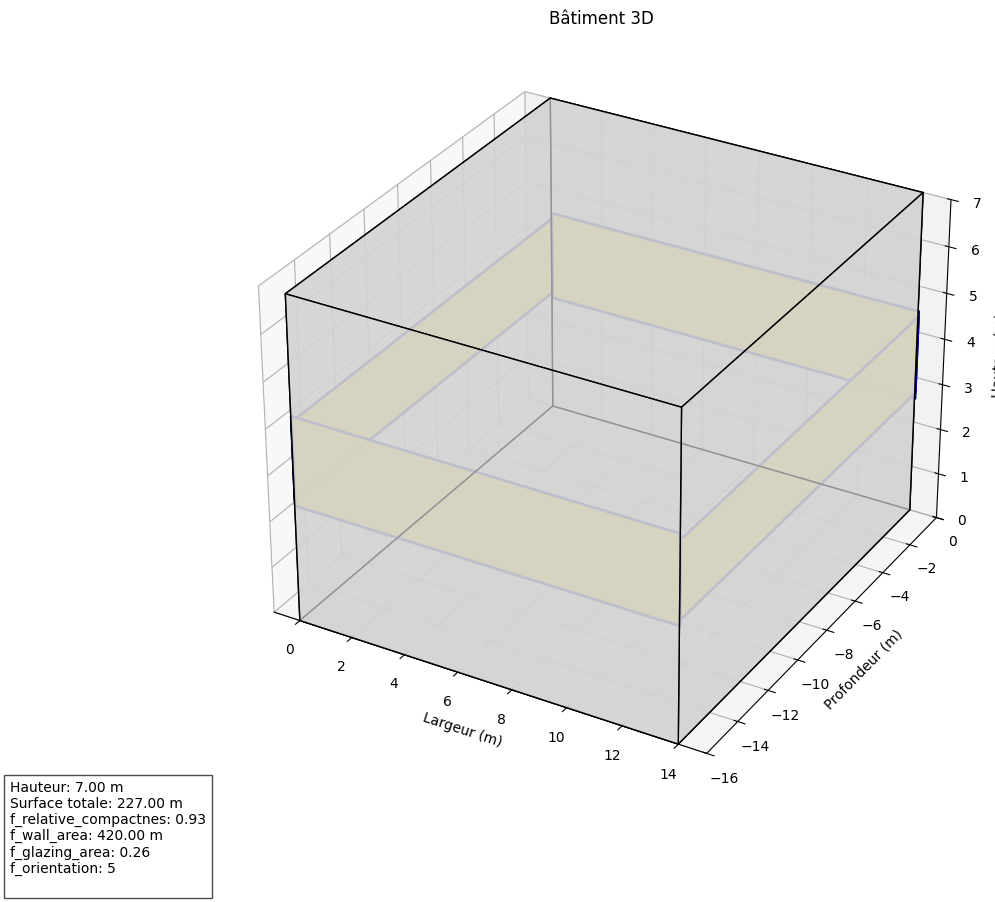

{'f_glazing_area': 0.25608897719286716, 'f_orientation': 5, 'f_overall_height': 7, 'f_relative_compactness': 0.9329582958097663, 'f_wall_area': 420}


In [4]:
variables=creer_batiment_3D()
print(variables)

**Qlearning**

In [5]:
param_names = ['f_glazing_area', 'f_orientation', 'f_overall_height', 'f_relative_compactness', 'f_wall_area']

#valeurs limites des paramètres
param_bounds = {
    'f_glazing_area': (0, 0.4),
    'f_orientation': (2, 5),
    'f_overall_height': (2.625, 15.75),
    'f_relative_compactness': (0.5, 1.0),
    'f_wall_area': (100, 3000)
}
# Taille des steps
param_steps = {
    'f_glazing_area':0.05,
    'f_orientation': 1,
    'f_overall_height': 1,
    'f_relative_compactness': 0.05,
    'f_wall_area': 10
}

#model_clim = joblib.load("/Users/sebastiendetheve/Documents/github/conso_energy/notebooks/saved_models/xgbregressor_normalized_ENB2012_data.csv_l_cooling_load.joblib")
#model_chauffage = joblib.load("/Users/sebastiendetheve/Documents/github/conso_energy/notebooks/saved_models/xgbregressor_normalized_ENB2012_data.csv_l_heating_load.joblib")

In [6]:
def reward_func(params):
    chauffage = (
        2.9999 +
        0.1179 * params['f_glazing_area'] +
        5534 * params['f_relative_compactness'] +
        1.1162 * params['f_overall_height'] +
        1674 * params['f_wall_area'] +
        500 * params['f_orientation']
    )
    clim = (
        0.0001 +
        0.0001 * params['f_glazing_area'] +
        0.0001 * params['f_relative_compactness'] +
        0.0001 * params['f_overall_height'] +
        0.0001 * params['f_wall_area'] +
        0.0001 * params['f_orientation']
    )
    #X = np.array([[params['f_glazing_area'],
    #               params['f_orientation'],
    #               params['f_overall_height'],
    #               params['f_relative_compactness'],
    #               params['f_wall_area']]])
    #chauffage = model_chauffage.predict(X)[0]
    #clim = model_clim.predict(X)[0]

    return -(chauffage + clim)

In [7]:
class QLearningAgent:
    def __init__(self, param_names, param_bounds, param_steps, alpha=0.1, gamma=0.9, epsilon=0.2):
        self.param_names = param_names
        self.param_bounds = param_bounds
        self.param_steps = param_steps
        self.actions = self._build_actions()
        self.q_table = defaultdict(float)
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon

    def _build_actions(self):
        actions = []
        for name in self.param_names:
            step = self.param_steps[name]
            actions.append((name, step))
            actions.append((name, -step))
        return actions

    def discretize(self, params):
        d = []
        for n in self.param_names:
            step = self.param_steps[n]
            if n == 'f_orientation':
                d.append(int(round(params[n])))
            else:
                d.append(int(round((params[n] - self.param_bounds[n][0]) / step)))
        return tuple(d)

    def choose_action(self, state):
        if np.random.rand() < self.epsilon:
            return self.actions[np.random.randint(len(self.actions))]
        q_vals = [self.q_table[(state, a)] for a in self.actions]
        return self.actions[np.argmax(q_vals)]

    def update(self, state, action, reward, next_state):
        best_next = max([self.q_table[(next_state, a)] for a in self.actions])
        self.q_table[(state, action)] += self.alpha * (reward + self.gamma * best_next - self.q_table[(state, action)])

    def run_episode(self, initial_params, reward_func, n_steps=20):
        params = initial_params.copy()
        state = self.discretize(params)
        for _ in range(n_steps):
            action = self.choose_action(state)
            param, delta = action
            # Appliquer l'action
            if param == 'f_orientation':
                params[param] = int((params[param] + delta) % 4)
            else:
                params[param] = np.clip(params[param] + delta, *self.param_bounds[param])
            next_state = self.discretize(params)
            reward = reward_func(params)
            self.update(state, action, reward, next_state)
            state = next_state
        return params, reward_func(params)

In [8]:
param_dropdown = widgets.Dropdown(
    options=[''] + param_names,
    value='',
    description='Paramètre fixe:',
    disabled=False,
)
button = widgets.Button(description="Lancer l'optimisation")
output = widgets.Output()

def on_button_clicked(b):
    with output:
        output.clear_output()
        param_to_fix = param_dropdown.value

        # Construire dynamiquement les listes pour QLearningAgent
        if param_to_fix and param_to_fix in param_names:
            q_param_names = [n for n in param_names if n != param_to_fix]
            q_param_bounds = {k: v for k, v in param_bounds.items() if k != param_to_fix}
            q_param_steps = {k: v for k, v in param_steps.items() if k != param_to_fix}
        else:
            q_param_names = param_names
            q_param_bounds = param_bounds
            q_param_steps = param_steps

        agent = QLearningAgent(q_param_names, q_param_bounds, q_param_steps, alpha=0.2, gamma=0.95, epsilon=0.3)
        best_params = None
        best_score = -np.inf

        for episode in range(100):
            params = variables.copy()
            if param_to_fix:
                params[param_to_fix] = variables[param_to_fix]
            agent.epsilon = max(0.01, agent.epsilon * 0.99)
            final_params, score = agent.run_episode(params, reward_func, n_steps=50)
            if score > best_score:
                best_score = score
                best_params = final_params.copy()

        print()
        print("Configuration de départ :")
        for k, v in variables.items():
            print(f"{k}: {v}")
        print(f"Consommation énergétique totale (chauffage + climatisation) : {-1*reward_func(variables):.2f}")

        print("\nMeilleure configuration trouvée:")
        for k, v in best_params.items():
            print(f"  {k}: {v}")
        print(f"Consommation énergétique totale (chauffage + climatisation) : {-1*best_score:.2f}")

button.on_click(on_button_clicked)
display(param_dropdown, button, output)

Dropdown(description='Paramètre fixe:', options=('', 'f_glazing_area', 'f_orientation', 'f_overall_height', 'f…

Button(description="Lancer l'optimisation", style=ButtonStyle())

Output()

**DQN**

In [9]:
def normalize_variables(variables, param_bounds, param_names):
    return np.array([
        (variables[name] - param_bounds[name][0]) / (param_bounds[name][1] - param_bounds[name][0])
        for name in param_names
    ])

# Initialisation à partir des variables réelles
state = normalize_variables(variables, param_bounds, param_names)

def denormalize_state(state, param_bounds, param_names):
    return {
        name: state[i] * (param_bounds[name][1] - param_bounds[name][0]) + param_bounds[name][0]
        for i, name in enumerate(param_names)
    }

In [10]:
def model_predict(state):

    param_names = ['f_glazing_area', 'f_orientation', 'f_overall_height', 'f_relative_compactness', 'f_wall_area']
    param_bounds = {
        'f_glazing_area': (0, 0.4),
        'f_orientation': (2, 5),
        'f_overall_height': (2.625, 15.75),
        'f_relative_compactness': (0.5, 1.0),
        'f_wall_area': (100, 3000)
    }
    params = {}
    for i, name in enumerate(param_names):
        min_val, max_val = param_bounds[name]
        params[name] = state[i] * (max_val - min_val) + min_val

    chauffage = (
        2.9999 +
        0.1179 * params['f_glazing_area'] +
        5534 * params['f_relative_compactness'] +
        1.1162 * params['f_overall_height'] +
        1674 * params['f_wall_area'] +
        500 * params['f_orientation']
    )
    clim = (
        0.0001 +
        0.0001 * params['f_glazing_area'] +
        0.0001 * params['f_relative_compactness'] +
        0.0001 * params['f_overall_height'] +
        0.0001 * params['f_wall_area'] +
        0.0001 * params['f_orientation']
    )
    return np.array([chauffage, clim])

In [11]:

class QNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, output_dim)
        )
    def forward(self, x):
        return self.net(x)

class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)
    def push(self, s, a, r, s2, d):
        self.buffer.append((s, a, r, s2, d))
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s2, d = map(np.array, zip(*batch))
        return (torch.FloatTensor(s), torch.LongTensor(a), torch.FloatTensor(r), torch.FloatTensor(s2), torch.FloatTensor(d))
    def __len__(self): return len(self.buffer)

class DQNAgent:
    def __init__(self, state_dim, action_dim, model_predict, gamma=0.99, lr=1e-3):
        self.q_net = QNetwork(state_dim, action_dim)
        self.target_net = QNetwork(state_dim, action_dim)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.gamma = gamma
        self.replay_buffer = ReplayBuffer()
        self.batch_size = 64
        self.model_predict = model_predict

    def select_action(self, state, epsilon):
        if random.random() < epsilon:
            return random.randint(0, 9)
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            return int(self.q_net(state_tensor).argmax().item())

    def train_step(self):
        if len(self.replay_buffer) < self.batch_size:
            return
        s, a, r, s2, d = self.replay_buffer.sample(self.batch_size)
        q_vals = self.q_net(s)
        target_q_vals = self.target_net(s2).max(1)[0]
        targets = r + self.gamma * target_q_vals * (1 - d)
        q_vals_action = q_vals.gather(1, a.unsqueeze(1)).squeeze()
        loss = (q_vals_action - targets.detach()).pow(2).mean()
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def update_target(self):
        self.target_net.load_state_dict(self.q_net.state_dict())

def apply_action(state, action_index):
    step = 0.01
    state = state.copy()
    param_idx = action_index // 2
    direction = 1 if action_index % 2 == 0 else -1
    state[param_idx] += direction * step
   
    if param_idx == 1:
        # Dénormaliser, arrondir à 2,3,4,5 puis renormaliser
        val = state[param_idx] * (param_bounds['f_orientation'][1] - param_bounds['f_orientation'][0]) + param_bounds['f_orientation'][0]
        val = int(np.clip(round(val), 2, 5))
        state[param_idx] = (val - param_bounds['f_orientation'][0]) / (param_bounds['f_orientation'][1] - param_bounds['f_orientation'][0])
    state = np.clip(state, 0, 1)
    return state

agent = DQNAgent(state_dim=5, action_dim=10, model_predict=model_predict)

n_episodes = 200
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.05
best_designs = []

# Choix du paramètre à bloquer pour le DQN
dqn_param_dropdown = widgets.Dropdown(
    options=[''] + param_names,
    value='',
    description='Paramètre fixe DQN:',
    disabled=False,
)
dqn_button = widgets.Button(description="Lancer DQN")
dqn_output = widgets.Output()
display(dqn_param_dropdown, dqn_button, dqn_output)

def run_dqn_optimization(b):
    with dqn_output:
        dqn_output.clear_output()
        param_to_fix_dqn = dqn_param_dropdown.value
        best_designs = []
        epsilon = 1.0
        for episode in range(n_episodes):
            state = normalize_variables(variables, param_bounds, param_names)
            total_reward = 0
            for step in range(50):
                if param_to_fix_dqn and param_to_fix_dqn in param_names:
                    idx_fix = param_names.index(param_to_fix_dqn)
                    state[idx_fix] = normalize_variables(variables, param_bounds, param_names)[idx_fix]
                action = agent.select_action(state, epsilon)
                next_state = apply_action(state, action)
                if param_to_fix_dqn and param_to_fix_dqn in param_names:
                    next_state[idx_fix] = normalize_variables(variables, param_bounds, param_names)[idx_fix]
                energy = model_predict(next_state)
                reward = -np.sum(energy)
                agent.replay_buffer.push(state, action, reward, next_state, False)
                agent.train_step()
                state = next_state
                total_reward += reward
            best_designs.append((total_reward, state.copy(), model_predict(state)))
            best_designs = sorted(best_designs, key=lambda x: x[0], reverse=True)[:50]
            agent.update_target()
            epsilon = max(epsilon * epsilon_decay, epsilon_min)
   
        # Visualisation des meilleurs designs
        data = []
        for reward, state, (heating, cooling) in best_designs[:5]:
            real_values = denormalize_state(state, param_bounds, param_names)
            data.append([
                reward,
                real_values['f_overall_height'],
                real_values['f_relative_compactness'],
                real_values['f_wall_area'],
                real_values['f_glazing_area'],
                real_values['f_orientation'],
                heating,
                cooling
            ])

        columns = ["total_reward", "overall_height", "relative_compactness", "wall_area", "glazing_area", "orientation", "heating", "cooling"]
        df = pd.DataFrame(data, columns=columns)
        print(df.head(10))

        
        
         
dqn_button.on_click(run_dqn_optimization)


Dropdown(description='Paramètre fixe DQN:', options=('', 'f_glazing_area', 'f_orientation', 'f_overall_height'…

Button(description='Lancer DQN', style=ButtonStyle())

Output()

**Version 2 agents avec MCP**

In [12]:

def reward_chauffage_from_state(state):
    energy = model_predict(state)
    return -energy[0]  # Chauffage

def reward_clim_from_state(state):
    energy = model_predict(state)
    return -energy[1]  # Clim

agent_chauffage = DQNAgent(state_dim=5, action_dim=10, model_predict=model_predict)
agent_clim = DQNAgent(state_dim=5, action_dim=10, model_predict=model_predict)

n_steps = 200
epsilon = 1.0
epsilon_decay = 0.99
epsilon_min = 0.05

# Etat initial (normalisé)
state = normalize_variables(variables, param_bounds, param_names)

for t in range(n_steps):
    # Agent chauffage agit
    action_ch = agent_chauffage.select_action(state, epsilon)
    next_state_ch = apply_action(state, action_ch)
    reward_ch = reward_chauffage_from_state(next_state_ch)
    agent_chauffage.replay_buffer.push(state, action_ch, reward_ch, next_state_ch, False)
    agent_chauffage.train_step()
    agent_chauffage.update_target()

    # Agent clim agit sur le nouvel état
    action_cl = agent_clim.select_action(next_state_ch, epsilon)
    next_state_cl = apply_action(next_state_ch, action_cl)
    reward_cl = reward_clim_from_state(next_state_cl)
    agent_clim.replay_buffer.push(next_state_ch, action_cl, reward_cl, next_state_cl, False)
    agent_clim.train_step()
    agent_clim.update_target()

    # Etat partagé pour la prochaine itération
    state = next_state_cl.copy()
    epsilon = max(epsilon * epsilon_decay, epsilon_min)

# Affichage de la configuration finale
final_params = denormalize_state(state, param_bounds, param_names)
print("Configuration finale optimisée (chauffage + clim DQN):")
for k, v in final_params.items():
    print(f"{k}: {v:.4f}")
energy = model_predict(state)
print(f"Chauffage: {energy[0]:.2f} | Clim: {energy[1]:.2f} | Total: {energy.sum():.2f}")

Configuration finale optimisée (chauffage + clim DQN):
f_glazing_area: 0.1361
f_orientation: 5.0000
f_overall_height: 5.2937
f_relative_compactness: 0.8530
f_wall_area: 187.0000
Chauffage: 320267.20 | Clim: 0.02 | Total: 320267.22


agents coopératifs

In [13]:
def reward_total_from_state(state):
    energy = model_predict(state)
    return -energy.sum()  # Total à minimiser

agent_chauffage = DQNAgent(state_dim=5, action_dim=10, model_predict=model_predict)
agent_clim = DQNAgent(state_dim=5, action_dim=10, model_predict=model_predict)

n_steps = 200
epsilon = 1.0
epsilon_decay = 0.99
epsilon_min = 0.05

state = normalize_variables(variables, param_bounds, param_names)

for t in range(n_steps):
    # Chaque agent propose une action
    action_ch = agent_chauffage.select_action(state, epsilon)
    next_state_ch = apply_action(state, action_ch)
    total_reward_ch = reward_total_from_state(next_state_ch)

    action_cl = agent_clim.select_action(state, epsilon)
    next_state_cl = apply_action(state, action_cl)
    total_reward_cl = reward_total_from_state(next_state_cl)

    # Négociation : on choisit l'action qui donne la meilleure reward totale
    if total_reward_ch > total_reward_cl:
        chosen_action = action_ch
        next_state = next_state_ch
    else:
        chosen_action = action_cl
        next_state = next_state_cl

    # On met à jour les deux agents avec la même transition (pour qu'ils apprennent à négocier)
    reward_ch = reward_chauffage_from_state(next_state)
    reward_cl = reward_clim_from_state(next_state)
    agent_chauffage.replay_buffer.push(state, chosen_action, reward_ch, next_state, False)
    agent_clim.replay_buffer.push(state, chosen_action, reward_cl, next_state, False)
    agent_chauffage.train_step()
    agent_clim.train_step()
    agent_chauffage.update_target()
    agent_clim.update_target()

    state = next_state.copy()
    epsilon = max(epsilon * epsilon_decay, epsilon_min)

# Affichage de la configuration finale
final_params = denormalize_state(state, param_bounds, param_names)
print("Configuration finale négociée (chauffage + clim DQN):")
for k, v in final_params.items():
    print(f"{k}: {v:.4f}")
energy = model_predict(state)
print(f"Chauffage: {energy[0]:.2f} | Clim: {energy[1]:.2f} | Total: {energy.sum():.2f}")

Configuration finale négociée (chauffage + clim DQN):
f_glazing_area: 0.2361
f_orientation: 5.0000
f_overall_height: 7.7875
f_relative_compactness: 0.9030
f_wall_area: 274.0000
Chauffage: 466184.69 | Clim: 0.03 | Total: 466184.72


Multi-agent hierarchique

In [45]:
class ManagerAgent:
    """Décide quel agent agit à chaque étape (chauffage ou clim), ou fixe une contrainte globale."""
    def __init__(self, mode="alternance"):
        self.mode = mode
    def choose_agent(self, t):
        if self.mode == "alternance":
            return "chauffage" if t % 2 == 0 else "clim"
        # On peut ajouter d'autres stratégies ici
        return "chauffage"

agent_manager = ManagerAgent(mode="alternance")
agent_chauffage = DQNAgent(state_dim=5, action_dim=10, model_predict=model_predict)
agent_clim = DQNAgent(state_dim=5, action_dim=10, model_predict=model_predict)

n_steps = 200
epsilon = 1.0
epsilon_decay = 0.99
epsilon_min = 0.05

state = normalize_variables(variables, param_bounds, param_names)

for t in range(n_steps):
    energy = model_predict(state)
    if energy[0] > energy[1]:
        agent_to_act = "chauffage"
    else:
        agent_to_act = "clim"

    if agent_to_act == "chauffage":
        action = agent_chauffage.select_action(state, epsilon)
        next_state = apply_action(state, action)
        reward = reward_chauffage_from_state(next_state)
        agent_chauffage.replay_buffer.push(state, action, reward, next_state, False)
        agent_chauffage.train_step()
        agent_chauffage.update_target()
    else:
        action = agent_clim.select_action(state, epsilon)
        next_state = apply_action(state, action)
        reward = reward_clim_from_state(next_state)
        agent_clim.replay_buffer.push(state, action, reward, next_state, False)
        agent_clim.train_step()
        agent_clim.update_target()
    state = next_state.copy()
    epsilon = max(epsilon * epsilon_decay, epsilon_min)

# Affichage de la configuration finale
final_params = denormalize_state(state, param_bounds, param_names)
print("Configuration finale hiérarchique (manager -> chauffage/clim DQN):")
for k, v in final_params.items():
    print(f"{k}: {v:.4f}")
energy = model_predict(state)
print(f"Chauffage: {energy[0]:.2f} | Clim: {energy[1]:.2f} | Total: {energy.sum():.2f}")

Configuration finale hiérarchique (manager -> chauffage/clim DQN):
f_glazing_area: 0.4000
f_orientation: 4.0000
f_overall_height: 8.3125
f_relative_compactness: 0.9125
f_wall_area: 216.0000
Chauffage: 368646.10 | Clim: 0.02 | Total: 368646.13
